# 🔹 Fundamentos dos Fluidos e Viscosidade
## Volume I – Capítulo 2 | Nível: Graduação/Pós-Graduação

**Objetivos de aprendizagem:**
- Diferenciar fluidos Newtonianos e não-Newtonianos
- Aplicar a Lei da Viscosidade de Newton
- Converter entre viscosidade dinâmica e cinemática
- Calcular tensões de cisalhamento em escoamentos simples

**Referência:** Lugon Junior (2026), *Fundamentos de Fenômenos de Transporte*, Vol I, Cap. 2.

In [1]:
# Importações padrão
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton

# Configurações de estilo para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 🔸 Lei da Viscosidade de Newton

Para fluidos Newtonianos, a tensão de cisalhamento é proporcional ao gradiente de velocidade:

$$\tau = \mu \frac{du}{dy} \quad [\text{Pa}]$$

onde:
- $\mu$ = viscosidade dinâmica [Pa·s]
- $du/dy$ = gradiente de velocidade [s⁻¹]

### Exemplo Interativo: Placa sobre camada de óleo

In [2]:
def forca_cisalhamento(mu, U, h, A):
    """
    Calcula a força tangencial para escoamento de Couette plano.
    
    Parâmetros:
    -----------
    mu : float
        Viscosidade dinâmica [Pa·s]
    U : float
        Velocidade da placa [m/s]
    h : float
        Espessura da camada de fluido [m]
    A : float
        Área da placa [m²]
    
    Retorna:
    --------
    F : float
        Força tangencial [N]
    """
    tau = mu * U / h  # Tensão de cisalhamento
    F = tau * A       # Força total
    return F

# Exercício Vol I, Cap 2, Ex 1
mu = 0.04      # Pa·s
U = 0.8        # m/s
h = 0.002      # m (2 mm)
A = 0.5        # m²

F = forca_cisalhamento(mu, U, h, A)
print(f"Força tangencial necessária: {F:.2f} N")
print(f"✓ Verificação: Valor esperado = 8.0 N")

Força tangencial necessária: 8.00 N
✓ Verificação: Valor esperado = 8.0 N


### 🎯 Desafio Interativo: Variação de parâmetros

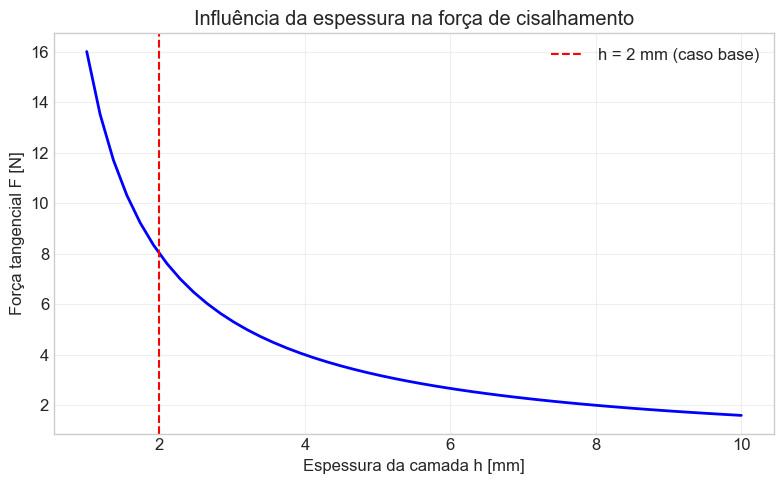

💡 Conclusão: F ∝ 1/h – reduzir a espessura pela metade DOBRA a força necessária!


In [4]:
# Varredura paramétrica: efeito da espessura h na força
h_values = np.linspace(0.001, 0.010, 50)  # 1 a 10 mm
F_values = [forca_cisalhamento(mu, U, h, A) for h in h_values]

plt.figure(figsize=(8, 5))
plt.plot(h_values*1000, F_values, 'b-', linewidth=2)
plt.xlabel('Espessura da camada h [mm]')
plt.ylabel('Força tangencial F [N]')
plt.title('Influência da espessura na força de cisalhamento')
plt.grid(True, alpha=0.3)
plt.axvline(x=2, color='r', linestyle='--', label='h = 2 mm (caso base)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"💡 Conclusão: F ∝ 1/h – reduzir a espessura pela metade DOBRA a força necessária!")

## 🔸 Fluidos Não-Newtonianos: Modelo de Herschel-Bulkley

Para fluidos com tensão de escoamento e comportamento de potência:

$$\tau = \tau_0 + K \dot{\gamma}^n$$

### Exercício Vol I, Cap 2, Ex 2 (Pós-Graduação)

In [5]:
def herschel_bulkley(tau0, K, n, gamma_dot):
    """
    Calcula tensão e viscosidade aparente para modelo Herschel-Bulkley.
    
    Parâmetros:
    -----------
    tau0 : float
        Tensão de escoamento [Pa]
    K : float
        Índice de consistência [Pa·sⁿ]
    n : float
        Índice de comportamento [adimensional]
    gamma_dot : float
        Taxa de cisalhamento [s⁻¹]
    
    Retorna:
    --------
    tau : float
        Tensão de cisalhamento [Pa]
    mu_ap : float
        Viscosidade aparente [Pa·s]
    """
    tau = tau0 + K * gamma_dot**n
    mu_ap = tau / gamma_dot if gamma_dot > 0 else np.inf
    return tau, mu_ap

# Parâmetros do exercício
tau0 = 15      # Pa
K = 8          # Pa·sⁿ
n = 0.6        # adimensional
gamma_dot = 50 # s⁻¹

tau, mu_ap = herschel_bulkley(tau0, K, n, gamma_dot)
print(f"Tensão de cisalhamento: τ = {tau:.2f} Pa")
print(f"Viscosidade aparente: μ_ap = {mu_ap:.3f} Pa·s")
print(f"✓ Verificação: τ ≈ 97.9 Pa, μ_ap ≈ 1.96 Pa·s")

Tensão de cisalhamento: τ = 98.65 Pa
Viscosidade aparente: μ_ap = 1.973 Pa·s
✓ Verificação: τ ≈ 97.9 Pa, μ_ap ≈ 1.96 Pa·s


### 📊 Visualização: Curva reológica

Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.


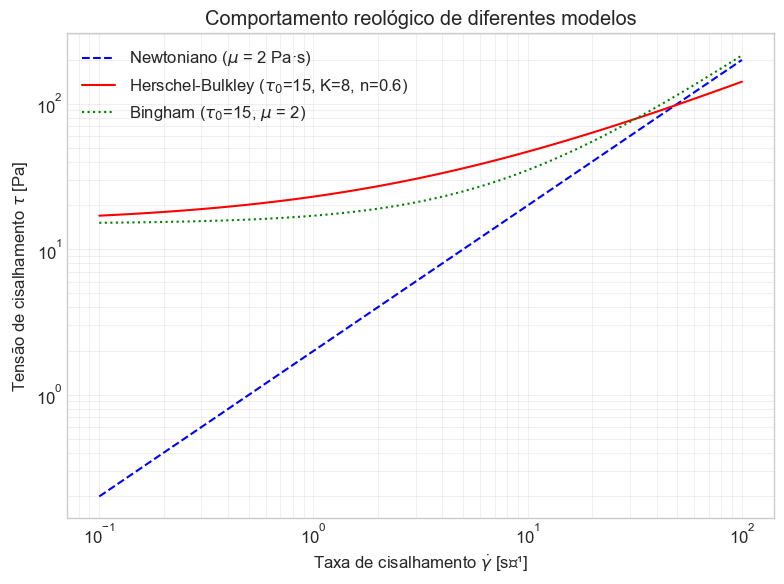

In [25]:
# Plot da curva τ vs γ̇ para diferentes modelos
gamma = np.logspace(-1, 2, 100)  # 0.1 a 100 s⁻¹

# Newtoniano (μ = 2 Pa·s)
tau_newton = 2.0 * gamma

# Herschel-Bulkley
tau_hb = tau0 + K * gamma**n

# Bingham (τ₀ = 15 Pa, μ = 2 Pa·s)
tau_bingham = np.where(gamma > 0, tau0 + 2.0*gamma, 0)

plt.figure(figsize=(8, 6))
plt.loglog(gamma, tau_newton, 'b--', label='Newtoniano ($\\mu$ = 2 Pa·s)')
plt.loglog(gamma, tau_hb, 'r-', label='Herschel-Bulkley ($\\tau_0$=15, K=8, n=0.6)')
plt.loglog(gamma, tau_bingham, 'g:', label='Bingham ($\\tau_0$=15, $\\mu$ = 2)')
plt.xlabel('Taxa de cisalhamento $\\dot{\\gamma}$ [s⁻¹]')
plt.ylabel('Tensão de cisalhamento $\\tau$ [Pa]')
plt.title('Comportamento reológico de diferentes modelos')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## ✅ Exercícios Propostos

1. **[Graduação]** Calcule a viscosidade cinemática para μ = 0.15 Pa·s e ρ = 850 kg/m³. Converta para centistokes.
2. **[Pós-Graduação]** Implemente a fórmula de Sutherland para viscosidade de gases e compare com valores tabelados para o ar.

> 💡 Dica: Use as células de código acima como template. Substitua os parâmetros e execute!

In [26]:
# Template para exercício 1
def viscosidade_cinematica(mu, rho):
    """Calcula viscosidade cinemática ν = μ/ρ"""
    nu = mu / rho  # m²/s
    nu_cSt = nu * 1e6  # converter para centistokes
    return nu, nu_cSt

# Seus valores aqui:
mu_ex = 0.15   # Pa·s
rho_ex = 850   # kg/m³

nu, nu_cSt = viscosidade_cinematica(mu_ex, rho_ex)
print(f"ν = {nu:.3e} m²/s = {nu_cSt:.1f} cSt")

ν = 1.765e-04 m²/s = 176.5 cSt
